### In this notebook we are going to test diffrent batch sizes in training our neural network model

We will use MNIST dataset; So the task is multiclass classification.

We will test batch sizes: 16, 32, 64, 128, 256, 512 and rank them based on:
#### Testing accuracy, Testing loss, Traning time

In [1]:
#Change directory for importing 

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
#Load and preprocess MNIST dataset from keras
from load_mnist import load_handwritten_digits

X_train, y_train, X_test, y_test = load_handwritten_digits()

In [3]:
import time #For calculating training time

batch_sizes = [16, 32, 64, 128, 256, 512]

accuracies = list()
losses = list()
times = list()

from build_model import build_mnist_model

In [4]:
for indx, btchsize in enumerate(batch_sizes):
    print(f"------------- batch size: {btchsize} ----------------")
    net = build_mnist_model()

    start = time.perf_counter() #Timer starts!

    net.fit(X = X_train,
           y = y_train,
           epoch = 5,
           batch_size = btchsize,
           monitor_every_n = 5)

    elapsed = time.perf_counter() - start #Timer stops!
    times.append(elapsed)

    accuracy, loss = net.evaluate(X_test, y_test)
    
    accuracies.append(accuracy)
    losses.append(loss)

    print(f"batch size: {btchsize}, time: {elapsed}")
    print(f"batch size: {btchsize}, accuracy: {accuracy}")
    print(f"batch size: {btchsize}, loss: {loss}")

------------- batch size: 16 ----------------
epoch: 5, loss: 0.057568516913568735
batch size: 16, time: 111.85849580005743
batch size: 16, accuracy: 0.9722
batch size: 16, loss: 0.09041179889751529
------------- batch size: 32 ----------------
epoch: 5, loss: 0.045037692842817174
batch size: 32, time: 62.05888679996133
batch size: 32, accuracy: 0.9761
batch size: 32, loss: 0.07979537856511355
------------- batch size: 64 ----------------
epoch: 5, loss: 0.04930862019350032
batch size: 64, time: 34.86290639999788
batch size: 64, accuracy: 0.9712
batch size: 64, loss: 0.09465603612833356
------------- batch size: 128 ----------------
epoch: 5, loss: 0.04779337101155003
batch size: 128, time: 22.482550199958496
batch size: 128, accuracy: 0.9701
batch size: 128, loss: 0.09619274081109995
------------- batch size: 256 ----------------
epoch: 5, loss: 0.05816174946975264
batch size: 256, time: 16.031978400074877
batch size: 256, accuracy: 0.9709
batch size: 256, loss: 0.1028124344597432
---

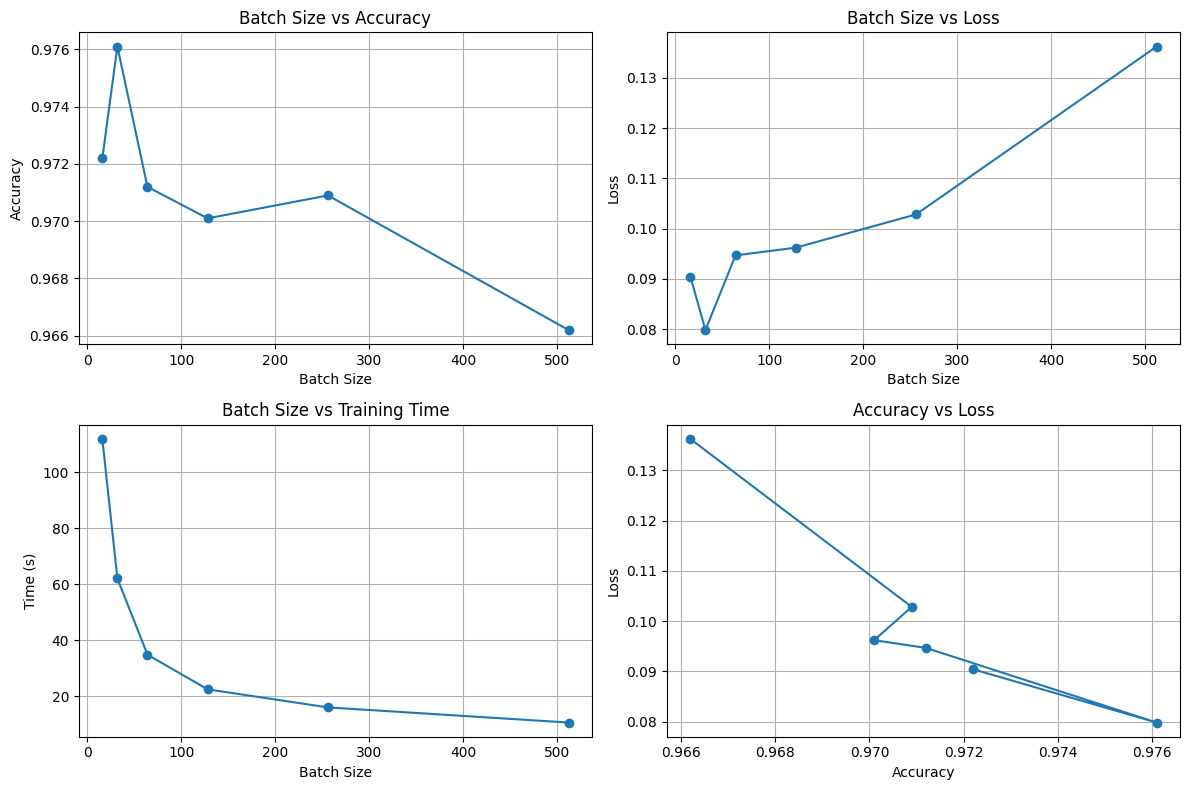

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Batch size vs Accuracy
axes[0, 0].plot(batch_sizes, accuracies, marker="o")
axes[0, 0].set_xlabel("Batch Size")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_title("Batch Size vs Accuracy")
axes[0, 0].grid()

# Batch size vs Loss
axes[0, 1].plot(batch_sizes, losses, marker="o")
axes[0, 1].set_xlabel("Batch Size")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_title("Batch Size vs Loss")
axes[0, 1].grid()

# Batch size vs Time
axes[1, 0].plot(batch_sizes, times, marker="o")
axes[1, 0].set_xlabel("Batch Size")
axes[1, 0].set_ylabel("Time (s)")
axes[1, 0].set_title("Batch Size vs Training Time")
axes[1, 0].grid()

# Accuracy vs Loss
axes[1, 1].plot(accuracies, losses, marker="o")
axes[1, 1].set_xlabel("Accuracy")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].set_title("Accuracy vs Loss")
axes[1, 1].grid()

plt.tight_layout()

plt.savefig("test_results\\batch_size_test.png")
plt.show()

### Results are intresting
Graphs indicate that batch size 32, has by far the best accuracy and loss values; However "Batch vs Training Time" also show strong relation between the batch size and training time meaning that higher batch size certainly means less training time.

Higher batch sizes like 256 and 512 have fast training times but lower accuracies; making the trade-of more visible.

The "Accuracy vs Loss" graph also shows that genrally, more accuracy can mean better loss but there are also some noises